In [1]:
xml_path = "/kaggle/input/datasets/trainingdatapro/cars-video-object-tracking/annotations.xml"

with open(xml_path, "r", encoding="utf-8") as f:
    for _ in range(100):   # first 100 lines
        print(f.readline().rstrip())

<?xml version="1.0" encoding="utf-8"?>
<annotations>
  <version>1.1</version>
  <meta>
    <task>
      <mode>interpolation</mode>
      <overlap>5</overlap>
      <start_frame>0</start_frame>
      <stop_frame>300</stop_frame>
      <segments>
        <segment>
          <start>0</start>
          <stop>300</stop>
        </segment>
      </segments>
      <owner>
        <username>Training Data</username>
      </owner>
      <labels>
        <label>
          <name>car</name>
          <color>#2a00ff</color>
          <type>rectangle</type>
          <attributes>
          </attributes>
        </label>
        <label>
          <name>minivan</name>
          <color>#b725ff</color>
          <type>rectangle</type>
          <attributes>
          </attributes>
        </label>
      </labels>
      <original_size>
        <width>1920</width>
        <height>1080</height>
      </original_size>
      <source>source.mp4</source>
    </task>
  </meta>
  <track id="0" label="car" source

In [2]:
import xml.etree.ElementTree as ET
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

# ===========================
# CHANGE THESE PATHS
# ===========================
DATASET = Path("/kaggle/input/datasets/trainingdatapro/cars-video-object-tracking")

IMAGE_DIR = DATASET / "images"
XML_FILE = DATASET / "annotations.xml"

# ===========================
# Read XML
# ===========================
tree = ET.parse(XML_FILE)
root = tree.getroot()

# Dictionary:
# frame_number -> list of detections
frame_annotations = {}

for track in root.findall("track"):

    track_id = int(track.attrib["id"])
    label = track.attrib["label"]

    for box in track.findall("box"):

        if box.attrib["outside"] == "1":
            continue

        frame = int(box.attrib["frame"])

        xtl = float(box.attrib["xtl"])
        ytl = float(box.attrib["ytl"])
        xbr = float(box.attrib["xbr"])
        ybr = float(box.attrib["ybr"])

        frame_annotations.setdefault(frame, []).append({
            "id": track_id,
            "label": label,
            "bbox": (xtl, ytl, xbr, ybr)
        })

print("Frames with annotations:", len(frame_annotations))

Frames with annotations: 901


In [3]:
from pathlib import Path

DATASET = Path("/kaggle/input/datasets/trainingdatapro/cars-video-object-tracking")

print("Folders:")
for item in DATASET.iterdir():
    print(item)

print("\nFirst 20 images:")
for f in sorted((DATASET/"images").iterdir())[:20]:
    print(f.name)

Folders:
/kaggle/input/datasets/trainingdatapro/cars-video-object-tracking/boxes
/kaggle/input/datasets/trainingdatapro/cars-video-object-tracking/images
/kaggle/input/datasets/trainingdatapro/cars-video-object-tracking/annotations.xml

First 20 images:
frame_000000.PNG
frame_000001.PNG
frame_000002.PNG
frame_000003.PNG
frame_000004.PNG
frame_000005.PNG
frame_000006.PNG
frame_000007.PNG
frame_000008.PNG
frame_000009.PNG
frame_000010.PNG
frame_000011.PNG
frame_000012.PNG
frame_000013.PNG
frame_000014.PNG
frame_000015.PNG
frame_000016.PNG
frame_000017.PNG
frame_000018.PNG
frame_000019.PNG


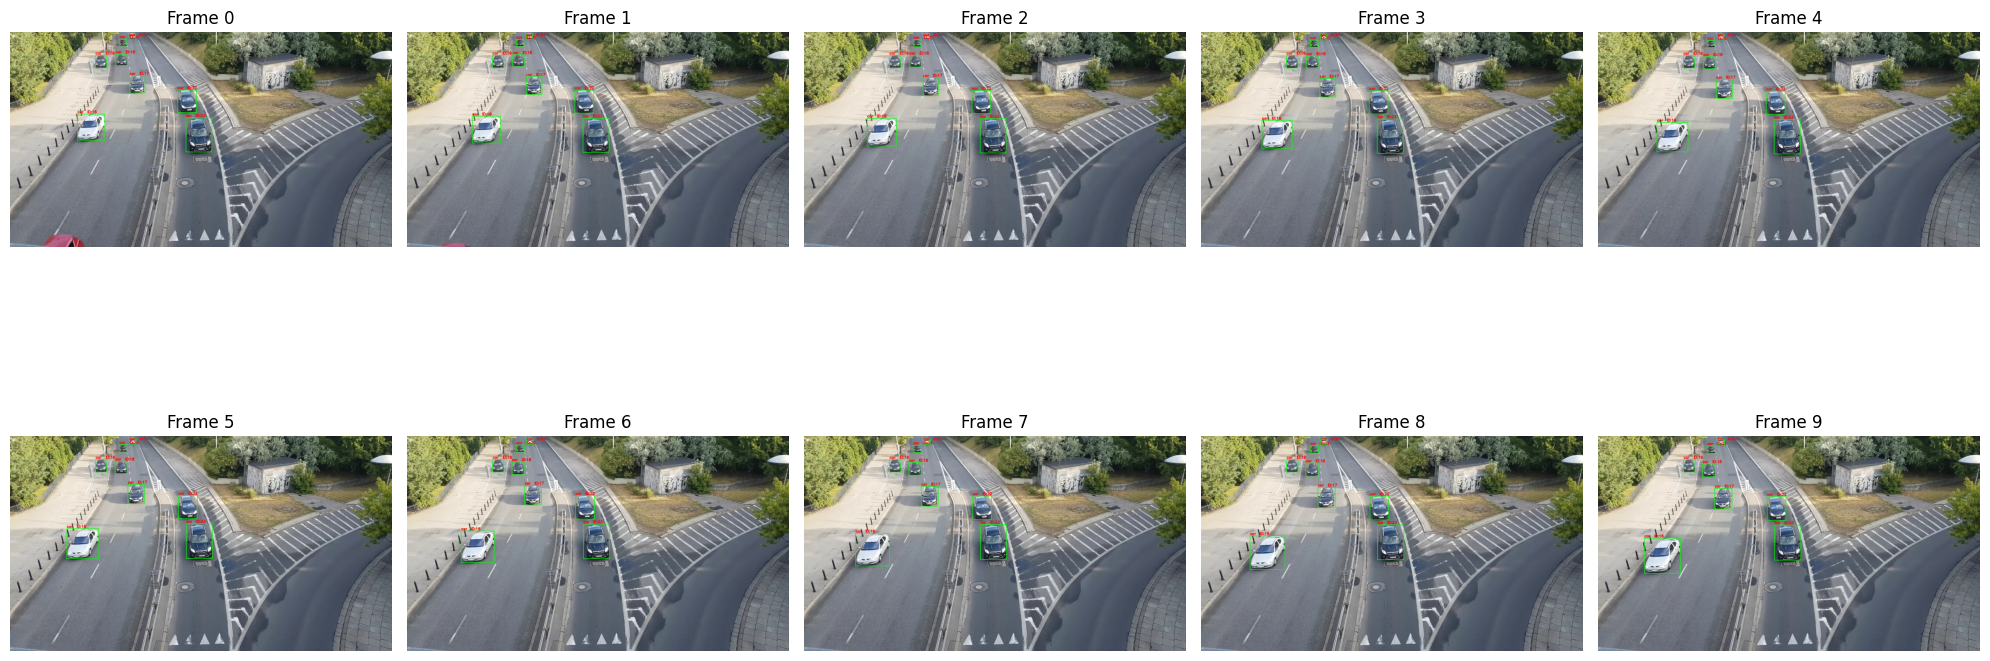

In [4]:
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

frames = sorted(frame_annotations.keys())[:10]

plt.figure(figsize=(20,10))

for i, frame_num in enumerate(frames):

    img_path = IMAGE_DIR / f"frame_{frame_num:06d}.PNG"

    img = cv2.imread(str(img_path))

    if img is None:
        print("Image not found:", img_path)
        continue

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Draw every object in this frame
    for obj in frame_annotations[frame_num]:

        xtl, ytl, xbr, ybr = obj["bbox"]

        cv2.rectangle(
            img,
            (int(xtl), int(ytl)),
            (int(xbr), int(ybr)),
            (0,255,0),
            2
        )

        cv2.putText(
            img,
            f'{obj["label"]}  ID:{obj["id"]}',
            (int(xtl), max(20, int(ytl)-5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255,0,0),
            2
        )

    plt.subplot(2,5,i+1)
    plt.imshow(img)
    plt.title(f"Frame {frame_num}")
    plt.axis("off")

plt.tight_layout()
plt.show()

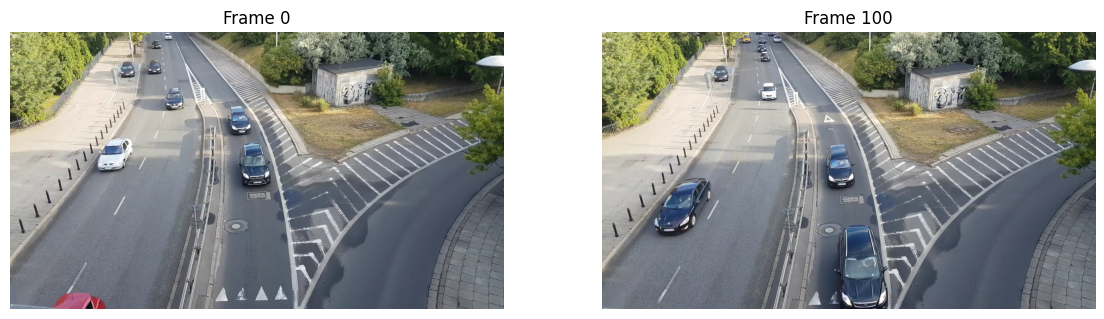

In [5]:
import cv2
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(14,6))

for idx, frame_num in enumerate([0, 100]):
    img = cv2.imread(str(IMAGE_DIR / f"frame_{frame_num:06d}.PNG"))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax[idx].imshow(img)
    ax[idx].set_title(f"Frame {frame_num}")
    ax[idx].axis("off")

plt.show()

In [6]:
# Clone ByteTrack
!git clone https://github.com/FoundationVision/ByteTrack.git

%cd ByteTrack

# Install dependencies
!pip install -q cython
!pip install -q onnx
!pip install -q lap
!pip install -q motmetrics
!pip install -q ninja

# Install ByteTrack
!pip install -v -e .

Cloning into 'ByteTrack'...
remote: Enumerating objects: 2007, done.
remote: Counting objects: 100% (329/329), done.
remote: Compressing objects: 100% (42/42), done.
remote: Total 2007 (delta 295), reused 287 (delta 287), pack-reused 1678 (from 1)
Receiving objects: 100% (2007/2007), 79.60 MiB | 30.22 MiB/s, done.
Resolving deltas: 100% (1159/1159), done.
/kaggle/working/ByteTrack
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.5/161.5 kB 7.1 MB/s eta 0:00:00
Using pip 24.1.2 from /usr/local/lib/python3.12/dist-packages/pip (python 3.12)
Obtaining file:///kaggle/working/ByteTrack
  Running command python setup.py egg_info
  running egg_info
  creating /tmp/pip-pip-egg-info-5262jcld/yolox.egg-info
  writing /tmp/pip-pip-egg-info-5262jcld/yolox.egg-info/PKG-INFO
  writing dependency_links to /tmp/pip-pip-egg-info-5262jcld/yolox.egg-info/dependency_links.txt
  writing top-level names to /tmp/pip-pip-egg-info-5262

In [7]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 2.5 MB/s eta 0:00:00


In [8]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import numpy as np

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [9]:
from pathlib import Path

for p in Path("/kaggle").rglob("best.pt"):
    print(p)

/kaggle/input/datasets/nadantikaap/yolo-weights/best.pt


In [10]:
MODEL_PATH = "/kaggle/input/datasets/nadantikaap/yolo-weights/best.pt"

model = YOLO(MODEL_PATH)

print("Loaded successfully!")

Loaded successfully!



image 1/1 /kaggle/input/datasets/trainingdatapro/cars-video-object-tracking/images/frame_000100.PNG: 384x640 6 cars, 271.1ms
Speed: 7.0ms preprocess, 271.1ms inference, 22.8ms postprocess per image at shape (1, 3, 384, 640)


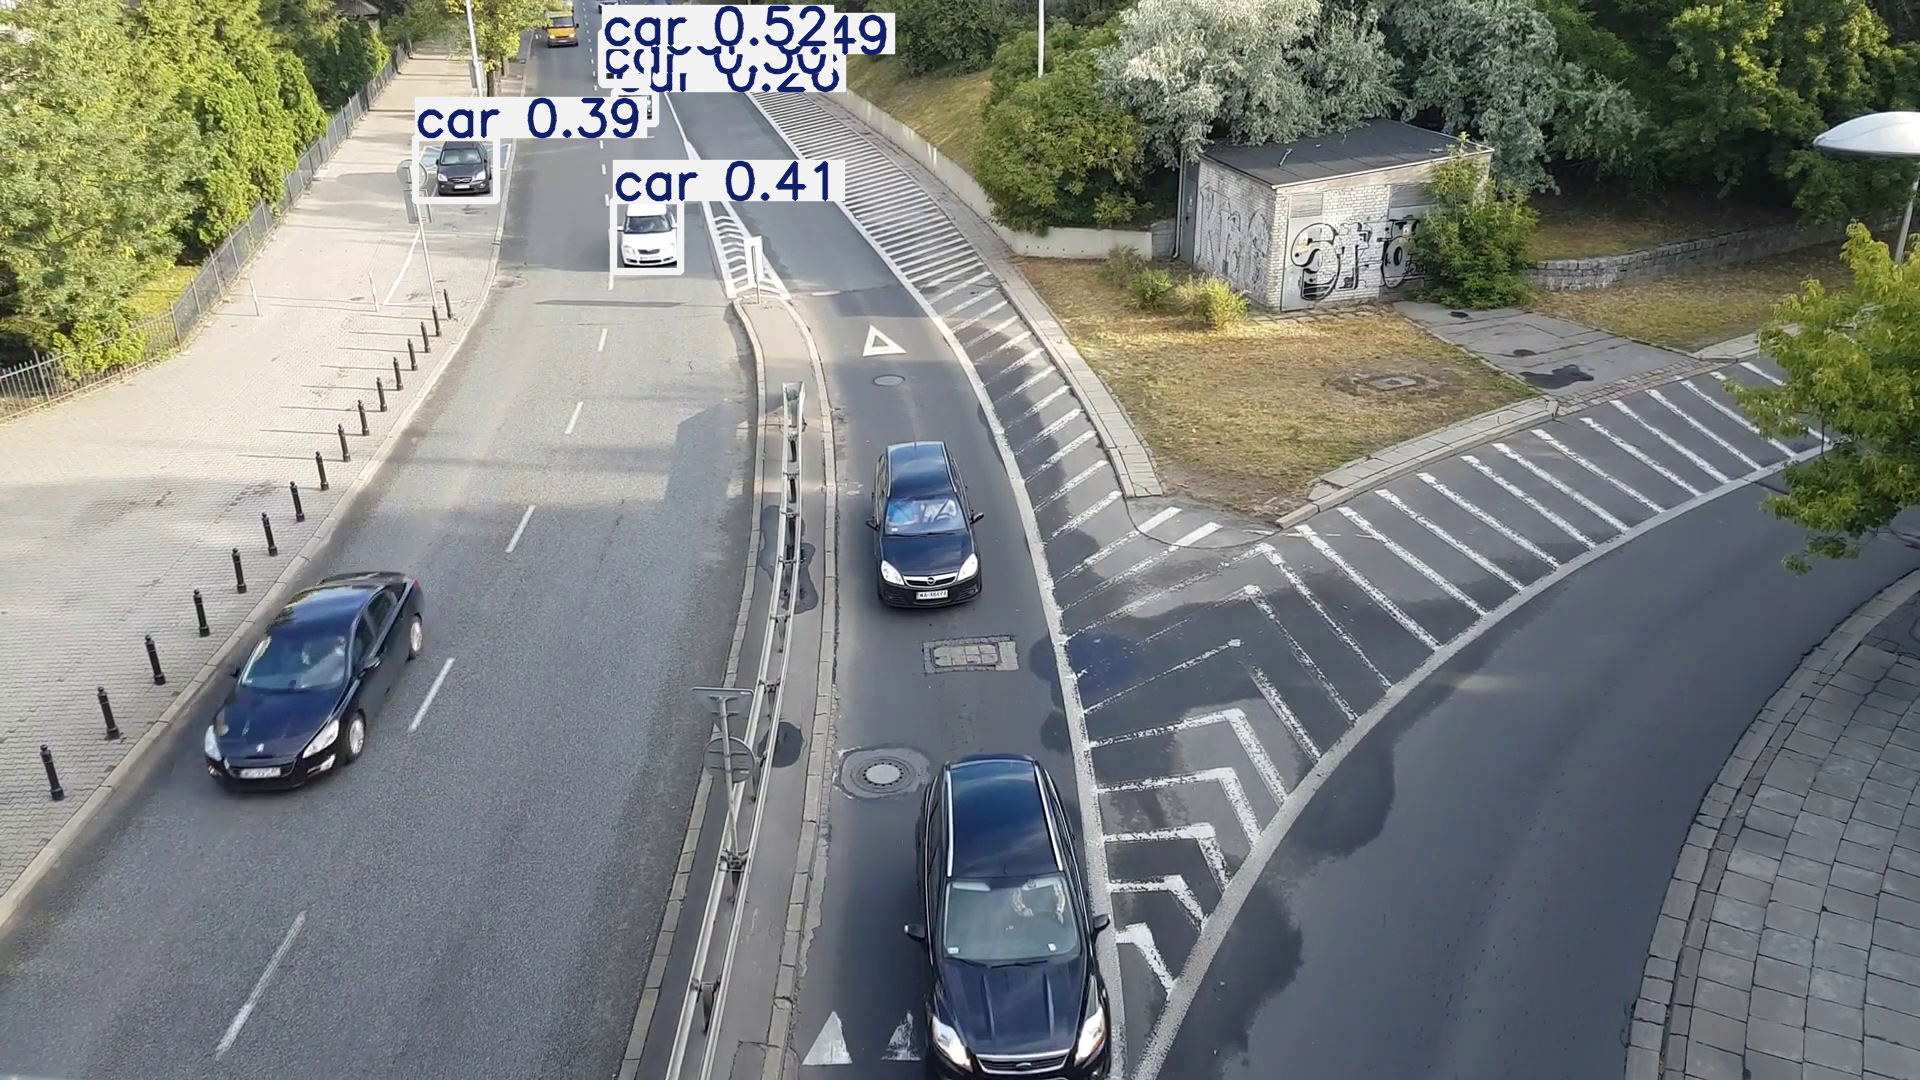

In [11]:
image_path="/kaggle/input/datasets/trainingdatapro/cars-video-object-tracking/images/frame_000100.PNG"

results=model(image_path)

results[0].show()

In [12]:
results = model.track(
    source="/kaggle/input/datasets/trainingdatapro/cars-video-object-tracking/images",
    tracker="bytetrack.yaml",
    persist=True,
    stream=True
)


image 1/301 /kaggle/input/datasets/trainingdatapro/cars-video-object-tracking/images/frame_000000.PNG: 384x640 5 cars, 115.4ms
image 2/301 /kaggle/input/datasets/trainingdatapro/cars-video-object-tracking/images/frame_000001.PNG: 384x640 5 cars, 117.7ms
image 3/301 /kaggle/input/datasets/trainingdatapro/cars-video-object-tracking/images/frame_000002.PNG: 384x640 6 cars, 118.4ms
image 4/301 /kaggle/input/datasets/trainingdatapro/cars-video-object-tracking/images/frame_000003.PNG: 384x640 6 cars, 115.2ms
image 5/301 /kaggle/input/datasets/trainingdatapro/cars-video-object-tracking/images/frame_000004.PNG: 384x640 4 cars, 116.4ms
image 6/301 /kaggle/input/datasets/trainingdatapro/cars-video-object-tracking/images/frame_000005.PNG: 384x640 4 cars, 114.0ms
image 7/301 /kaggle/input/datasets/trainingdatapro/cars-video-object-tracking/images/frame_000006.PNG: 384x640 4 cars, 115.5ms
image 8/301 /kaggle/input/datasets/trainingdatapro/cars-video-object-tracking/images/frame_000007.PNG: 384x640

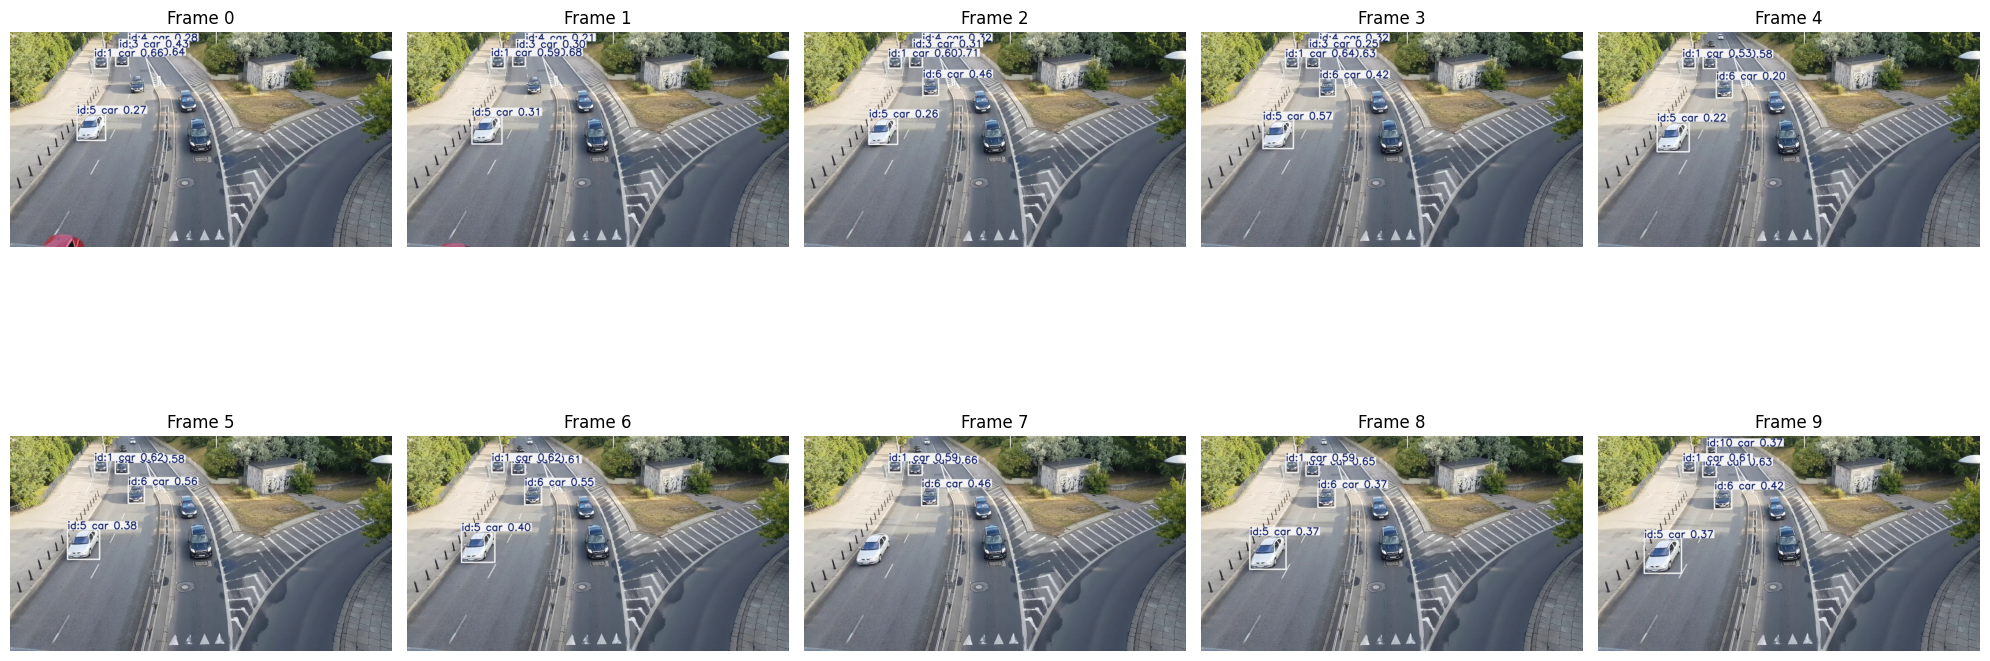

In [13]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

model=YOLO(MODEL_PATH)

results=model.track(
    source="/kaggle/input/datasets/trainingdatapro/cars-video-object-tracking/images",
    tracker="bytetrack.yaml",
    stream=True,
    persist=True
)

frames=[]

for i,r in enumerate(results):

    frame=r.plot()

    frames.append(frame)

    if i==9:
        break

plt.figure(figsize=(20,10))

for i,f in enumerate(frames):

    plt.subplot(2,5,i+1)

    plt.imshow(cv2.cvtColor(f,cv2.COLOR_BGR2RGB))

    plt.title(f"Frame {i}")

    plt.axis("off")

plt.tight_layout()
plt.show()